In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##  1 .LOAD DATA

In [3]:
df = pd.read_csv('car data.csv')
print("=" * 60)
print(" DATA OVERVIEW")
print("=" * 60)
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(df.head(3).to_string())


 DATA OVERVIEW
Rows: 301  |  Columns: 9
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type Transmission  Owner
0     ritz  2014           3.35           5.59       27000    Petrol       Dealer       Manual      0
1      sx4  2013           4.75           9.54       43000    Diesel       Dealer       Manual      0
2     ciaz  2017           7.25           9.85        6900    Petrol       Dealer       Manual      0


## 2. FEATURE ENGINEERING

In [4]:
print("\n" + "=" * 60)
print(" FEATURE ENGINEERING")
print("=" * 60)

# Car age is more informative than raw Year
df["Car_Age"] = 2024 - df["Year"]

# Price depreciation ratio (how much value has been lost)
df["Depreciation_Ratio"] = df["Present_Price"] / (df["Present_Price"] - df["Selling_Price"] + 0.001)

# KMs per year (usage intensity)
df["KMs_Per_Year"] = df["Driven_kms"] / (df["Car_Age"] + 1)

print("New features created: Car_Age, Depreciation_Ratio, KMs_Per_Year")
print(df[["Car_Age", "Depreciation_Ratio", "KMs_Per_Year"]].describe().round(2).to_string())



 FEATURE ENGINEERING
New features created: Car_Age, Depreciation_Ratio, KMs_Per_Year
       Car_Age  Depreciation_Ratio  KMs_Per_Year
count   301.00              301.00        301.00
mean     10.37                5.05       3034.76
std       2.89                8.26       2437.18
min       6.00                1.12         55.56
25%       8.00                2.02       1500.00
50%      10.00                2.89       2760.00
75%      12.00                4.75       4010.15
max      21.00               92.48      29411.76


## 3. PREPROCESSING

In [7]:
print("\n" + "=" * 60)
print(" PREPROCESSING")
print("=" * 60)

# Encode categorical variables
le = LabelEncoder()
cat_cols = ["Fuel_Type", "Selling_type", "Transmission"]
for col in cat_cols:
    df[col + "_enc"] = le.fit_transform(df[col])
    mapping = {cls: int(idx) for cls, idx in zip(le.classes_, le.transform(le.classes_))}
    print(f"  {col}: {mapping}")
    
# Drop original categorical & non-feature columns
feature_cols = [
    "Car_Age", "Present_Price", "Driven_kms", "Owner",
    "Fuel_Type_enc", "Selling_type_enc", "Transmission_enc",
    "Depreciation_Ratio", "KMs_Per_Year"
]

X = df[feature_cols]
y = df["Selling_Price"]

print(f"\nFeatures used ({len(feature_cols)}): {feature_cols}")
print(f"Target: Selling_Price  |  Range: ₹{y.min():.2f}L – ₹{y.max():.2f}L")



 PREPROCESSING
  Fuel_Type: {'CNG': 0, 'Diesel': 1, 'Petrol': 2}
  Selling_type: {'Dealer': 0, 'Individual': 1}
  Transmission: {'Automatic': 0, 'Manual': 1}

Features used (9): ['Car_Age', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type_enc', 'Selling_type_enc', 'Transmission_enc', 'Depreciation_Ratio', 'KMs_Per_Year']
Target: Selling_Price  |  Range: ₹0.10L – ₹35.00L


## 4. TRAIN / TEST SPLIT

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain set: {X_train.shape[0]} samples  |  Test set: {X_test.shape[0]} samples")



Train set: 240 samples  |  Test set: 61 samples


## 5. TRAIN THREE MODELS

In [11]:

# ─────────────────────────────────────────────
#  TRAINTHREE MODELS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print(" MODEL TRAINING & EVALUATION")
print("=" * 60)

models = {
    "Linear Regression":    LinearRegression(),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=5, scoring="r2").mean()

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2, "CV R²": cv}
    print(f"\n  {name}")
    print(f"    MAE  = ₹{mae:.4f}L   RMSE = ₹{rmse:.4f}L   R² = {r2:.4f}   CV R² = {cv:.4f}")

best_model_name = max(results, key=lambda k: results[k]["R²"])
best_model      = models[best_model_name]
print(f"\n   Best Model: {best_model_name}  (R² = {results[best_model_name]['R²']:.4f})")



 MODEL TRAINING & EVALUATION

  Linear Regression
    MAE  = ₹1.1754L   RMSE = ₹1.8661L   R² = 0.8488   CV R² = -19.6520

  Random Forest
    MAE  = ₹0.4160L   RMSE = ₹0.7058L   R² = 0.9784   CV R² = 0.5322

  Gradient Boosting
    MAE  = ₹0.3195L   RMSE = ₹0.5922L   R² = 0.9848   CV R² = 0.2371

   Best Model: Gradient Boosting  (R² = 0.9848)


## 6. FEATURE IMPORTANCE (best model if RF/GB)

In [13]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("\n" + "=" * 60)
    print(" FEATURE IMPORTANCE")
    print("=" * 60)
    for feat, imp in importances.items():
        bar = "█" * int(imp * 40)
        print(f"  {feat:<22} {bar}  {imp:.4f}")



 FEATURE IMPORTANCE
  Present_Price          ███████████████████████████████████  0.8809
  Depreciation_Ratio     ███  0.0929
  Car_Age                  0.0161
  Driven_kms               0.0076
  KMs_Per_Year             0.0022
  Fuel_Type_enc            0.0001
  Transmission_enc         0.0001
  Owner                    0.0000
  Selling_type_enc         0.0000


## 7. VISUALIZATIONS 

Text(0.5, 1.0, '📊 Summary Table')

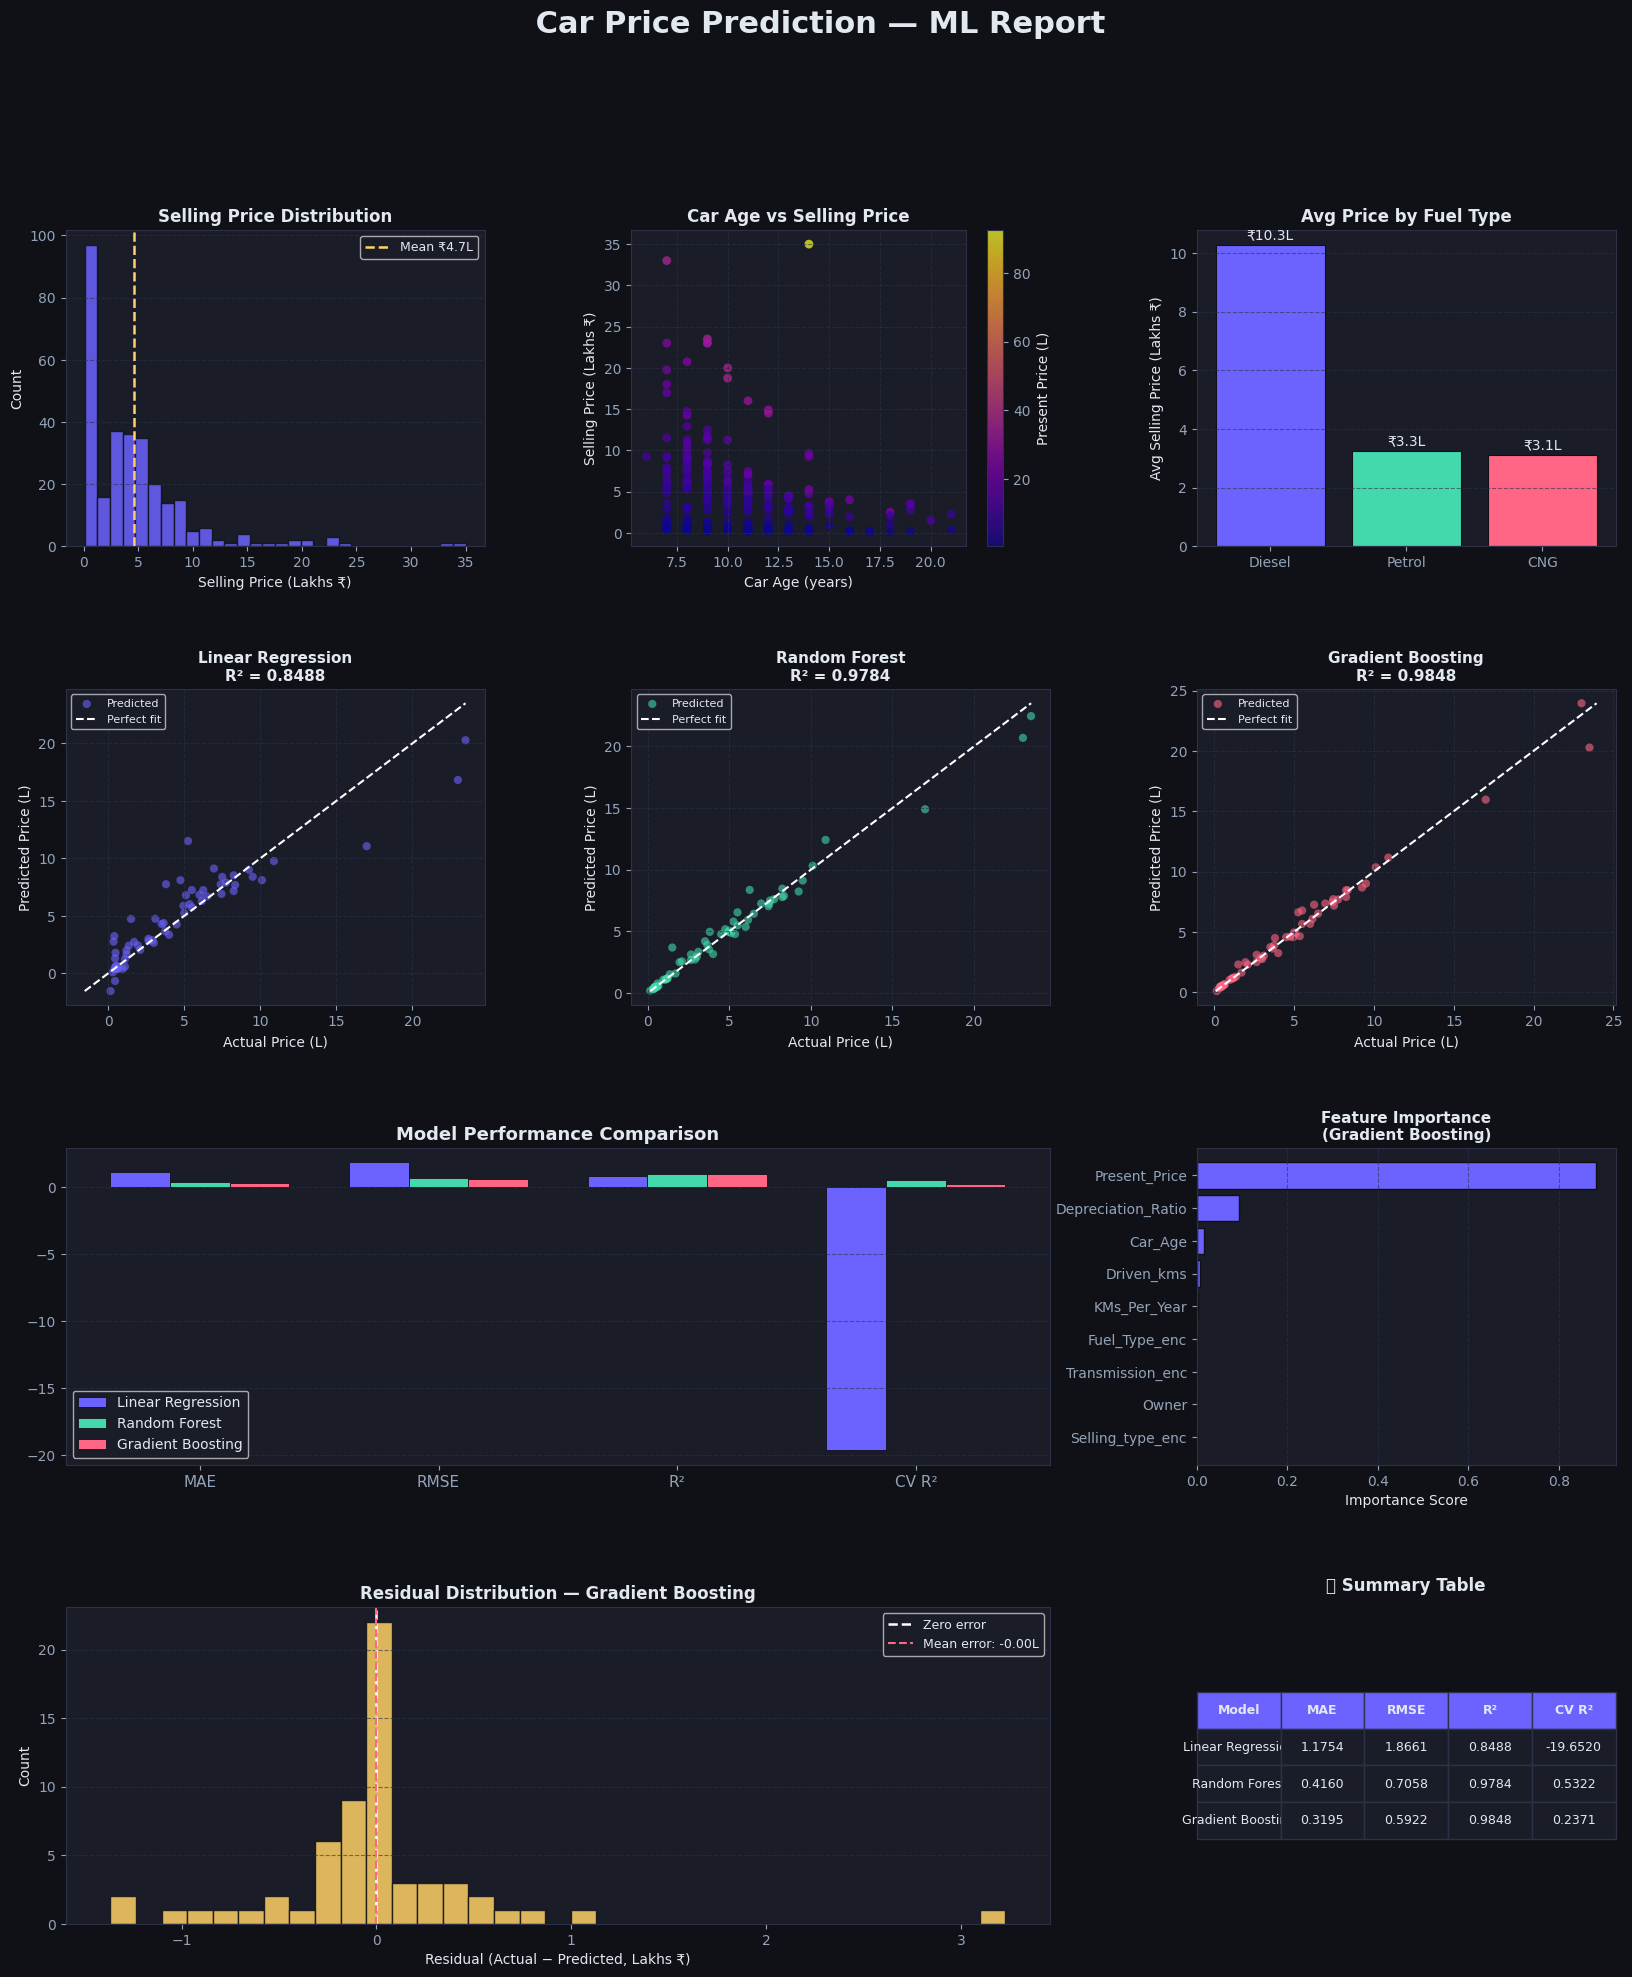

In [16]:
PALETTE = {
    "bg":       "#0f1117",
    "panel":    "#1a1d27",
    "accent1":  "#6c63ff",
    "accent2":  "#ff6584",
    "accent3":  "#43d9ad",
    "accent4":  "#ffd166",
    "text":     "#e2e8f0",
    "subtext":  "#94a3b8",
    "grid":     "#2d3148",
}

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["grid"],
    "axes.labelcolor":   PALETTE["text"],
    "xtick.color":       PALETTE["subtext"],
    "ytick.color":       PALETTE["subtext"],
    "text.color":        PALETTE["text"],
    "grid.color":        PALETTE["grid"],
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
})

fig = plt.figure(figsize=(20, 22), facecolor=PALETTE["bg"])
fig.suptitle(" Car Price Prediction — ML Report", fontsize=22, fontweight="bold",
             color=PALETTE["text"], y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Selling Price Distribution ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["Selling_Price"], bins=30, color=PALETTE["accent1"], edgecolor=PALETTE["bg"], alpha=0.85)
ax1.axvline(df["Selling_Price"].mean(), color=PALETTE["accent4"], linestyle="--", linewidth=1.8,
            label=f"Mean ₹{df['Selling_Price'].mean():.1f}L")
ax1.set_title("Selling Price Distribution", fontweight="bold", fontsize=12)
ax1.set_xlabel("Selling Price (Lakhs ₹)")
ax1.set_ylabel("Count")
ax1.legend(fontsize=9)
ax1.grid(True, axis="y")

# ── Panel 2: Car Age vs Selling Price ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sc = ax2.scatter(df["Car_Age"], df["Selling_Price"],
                 c=df["Present_Price"], cmap="plasma",
                 alpha=0.75, s=40, edgecolors="none")
plt.colorbar(sc, ax=ax2, label="Present Price (L)")
ax2.set_title("Car Age vs Selling Price", fontweight="bold", fontsize=12)
ax2.set_xlabel("Car Age (years)")
ax2.set_ylabel("Selling Price (Lakhs ₹)")
ax2.grid(True)

# ── Panel 3: Fuel Type Breakdown ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fuel_avg = df.groupby("Fuel_Type")["Selling_Price"].mean().sort_values(ascending=False)
colors_bar = [PALETTE["accent1"], PALETTE["accent3"], PALETTE["accent2"]]
bars = ax3.bar(fuel_avg.index, fuel_avg.values, color=colors_bar[:len(fuel_avg)],
               edgecolor=PALETTE["bg"], linewidth=0.8)
for bar, val in zip(bars, fuel_avg.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"₹{val:.1f}L", ha="center", va="bottom", fontsize=10, color=PALETTE["text"])
ax3.set_title("Avg Price by Fuel Type", fontweight="bold", fontsize=12)
ax3.set_ylabel("Avg Selling Price (Lakhs ₹)")
ax3.grid(True, axis="y")

# ── Panel 4–6: Actual vs Predicted for each model ────────────────
model_colors = [PALETTE["accent1"], PALETTE["accent3"], PALETTE["accent2"]]
model_names  = list(predictions.keys())

for i, (mname, mpred) in enumerate(predictions.items()):
    ax = fig.add_subplot(gs[1, i])
    ax.scatter(y_test, mpred, alpha=0.6, s=35,
               color=model_colors[i], edgecolors="none", label="Predicted")
    lims = [min(y_test.min(), mpred.min()), max(y_test.max(), mpred.max())]
    ax.plot(lims, lims, "w--", linewidth=1.5, label="Perfect fit")
    r2 = results[mname]["R²"]
    ax.set_title(f"{mname}\nR² = {r2:.4f}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Actual Price (L)")
    ax.set_ylabel("Predicted Price (L)")
    ax.legend(fontsize=8)
    ax.grid(True)

# ── Panel 7: Model Comparison Bar Chart ──────────────────────────
ax7 = fig.add_subplot(gs[2, :2])
metrics   = ["MAE", "RMSE", "R²", "CV R²"]
x         = np.arange(len(metrics))
bar_width = 0.25

for i, (mname, mres) in enumerate(results.items()):
    vals = [mres[m] for m in metrics]
    bars = ax7.bar(x + i * bar_width, vals, bar_width,
                   label=mname, color=model_colors[i],
                   edgecolor=PALETTE["bg"], linewidth=0.6)

ax7.set_title("Model Performance Comparison", fontweight="bold", fontsize=13)
ax7.set_xticks(x + bar_width)
ax7.set_xticklabels(metrics, fontsize=11)
ax7.legend(fontsize=10)
ax7.grid(True, axis="y")

# ── Panel 8: Feature Importance ──────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
if hasattr(best_model, "feature_importances_"):
    imp_sorted = importances.sort_values()
    colors_imp = [PALETTE["accent1"] if v >= imp_sorted.median() else PALETTE["subtext"]
                  for v in imp_sorted.values]
    ax8.barh(imp_sorted.index, imp_sorted.values,
             color=colors_imp, edgecolor=PALETTE["bg"])
    ax8.set_title(f"Feature Importance\n({best_model_name})", fontweight="bold", fontsize=11)
    ax8.set_xlabel("Importance Score")
    ax8.grid(True, axis="x")

# ── Panel 9: Residuals Distribution ──────────────────────────────
ax9 = fig.add_subplot(gs[3, :2])
best_pred = predictions[best_model_name]
residuals = y_test.values - best_pred
ax9.hist(residuals, bins=35, color=PALETTE["accent4"], edgecolor=PALETTE["bg"], alpha=0.85)
ax9.axvline(0, color="white", linestyle="--", linewidth=1.8, label="Zero error")
ax9.axvline(residuals.mean(), color=PALETTE["accent2"], linestyle="--", linewidth=1.5,
            label=f"Mean error: {residuals.mean():.2f}L")
ax9.set_title(f"Residual Distribution — {best_model_name}", fontweight="bold", fontsize=12)
ax9.set_xlabel("Residual (Actual − Predicted, Lakhs ₹)")
ax9.set_ylabel("Count")
ax9.legend(fontsize=9)
ax9.grid(True, axis="y")

# ── Panel 10: Metrics Summary Table ──────────────────────────────
ax10 = fig.add_subplot(gs[3, 2])
ax10.axis("off")
table_data = [[name] + [f"{results[name][m]:.4f}" for m in ["MAE", "RMSE", "R²", "CV R²"]]
              for name in results]
col_labels = ["Model", "MAE", "RMSE", "R²", "CV R²"]
tbl = ax10.table(cellText=table_data, colLabels=col_labels,
                  cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.2)

for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(PALETTE["panel"] if row > 0 else PALETTE["accent1"])
    cell.set_edgecolor(PALETTE["grid"])
    cell.set_text_props(color=PALETTE["text"], fontweight="bold" if row == 0 else "normal")

ax10.set_title("📊 Summary Table", fontweight="bold", fontsize=12, pad=12)



## 8. SAMPLE PREDICTIONS

In [17]:
print("\n" + "=" * 60)
print(" SAMPLE PREDICTIONS (Best Model)")
print("=" * 60)
sample = X_test.head(8).copy()
actual = y_test.head(8).values
predicted = best_model.predict(sample)

for i, (act, pred) in enumerate(zip(actual, predicted)):
    diff = act - pred
    icon = "✅" if abs(diff) < 1 else ("⚠️ " if abs(diff) < 2 else "❌")
    print(f"  {icon}  Actual: ₹{act:.2f}L   Predicted: ₹{pred:.2f}L   Error: ₹{diff:+.2f}L")



 SAMPLE PREDICTIONS (Best Model)
  ✅  Actual: ₹0.35L   Predicted: ₹0.44L   Error: ₹-0.09L
  ✅  Actual: ₹10.11L   Predicted: ₹10.36L   Error: ₹-0.25L
  ✅  Actual: ₹4.95L   Predicted: ₹4.56L   Error: ₹+0.39L
  ✅  Actual: ₹0.15L   Predicted: ₹0.09L   Error: ₹+0.06L
  ✅  Actual: ₹6.95L   Predicted: ₹7.35L   Error: ₹-0.40L
  ✅  Actual: ₹7.45L   Predicted: ₹7.71L   Error: ₹-0.26L
  ✅  Actual: ₹1.10L   Predicted: ₹1.12L   Error: ₹-0.02L
  ✅  Actual: ₹0.50L   Predicted: ₹0.52L   Error: ₹-0.02L
